# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [1]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [2]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '2'

In [3]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [4]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:08.405000,0.02,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:11.152000,0.02,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,2,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:13.755000,0.02,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,3,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:16.422000,0.02,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,4,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-06T21:32:19.023000,0.02,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,5,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2951,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:12.764827,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,16,L4,None,True
2952,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:14.184890,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,16,L4,None,True
2953,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:15.604952,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,16,L4,None,True
2954,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-07T09:10:17.025015,0.30,22:17:55.38,-08:21:03.70,DOMEFLAT,FLAT,POLAR,2,1,...,Normal,9915,Gain 2,1.0,Conventional,2,16,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [5]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs2/20250706_s4c2_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     167   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   261R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   261R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   261R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   261R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   261R x 13C   [I11, D2

Then we plot the science frame using the `sparc4.product_plots` library

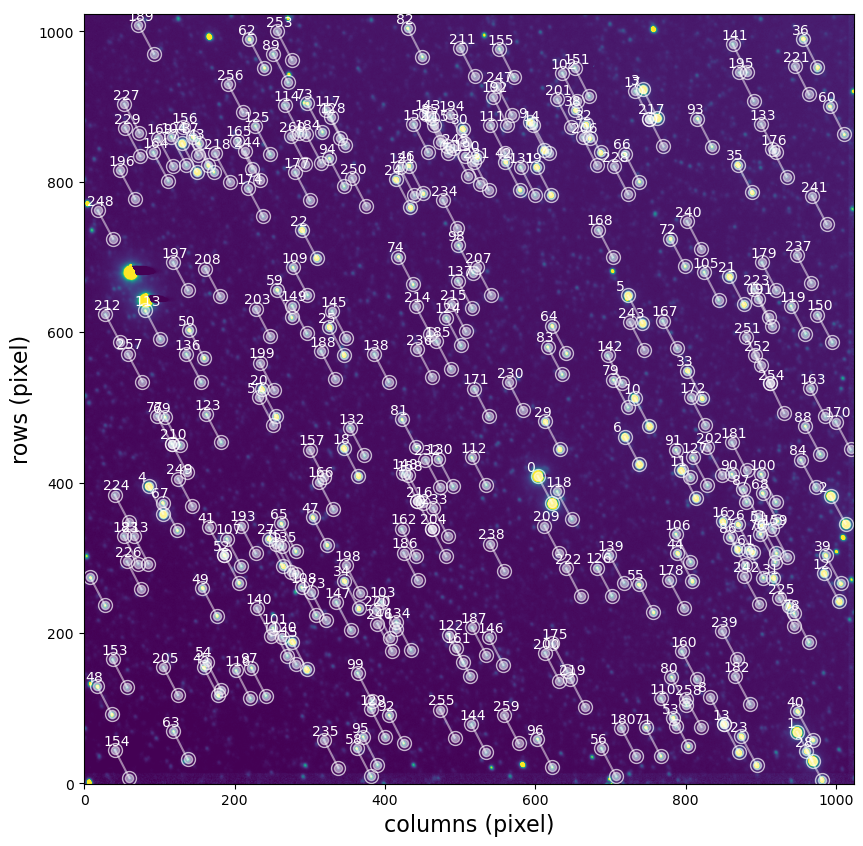

In [6]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [7]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.125051,-24.248629,622.485412,372.299639,5.974038,5.974038,-12.413886,0.000734,-10.724696,0.000709,10,0
1,1,258.088658,-24.279829,968.727266,30.117083,5.110801,5.110801,-11.949766,0.000949,-10.718408,0.000591,10,0
2,2,258.084863,-24.250240,1012.615093,345.225884,4.722863,4.722863,-11.578804,0.001184,-10.731801,0.000524,10,0
3,3,258.111910,-24.200030,762.362493,885.379754,4.662213,4.662213,-11.089371,0.001610,-10.742490,0.000419,10,0
4,4,258.178336,-24.251046,105.087900,358.386515,4.715600,4.715600,-10.918550,0.001794,-10.699034,0.000454,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,256,258.168778,-24.200555,211.157107,892.304378,4.455920,4.455920,-6.606784,0.067549,-10.726366,0.000476,10,0
257,257,258.181644,-24.234562,77.423580,534.402070,4.216761,4.216761,-6.703848,0.063117,-10.707283,0.000610,10,0
258,258,258.103949,-24.276040,820.783852,74.859544,4.622994,4.622994,-7.832784,0.022678,-10.713694,0.000587,10,0
259,259,258.128873,-24.278601,577.822650,53.316642,4.387341,4.387341,-6.230036,0.094326,-10.700307,0.000489,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

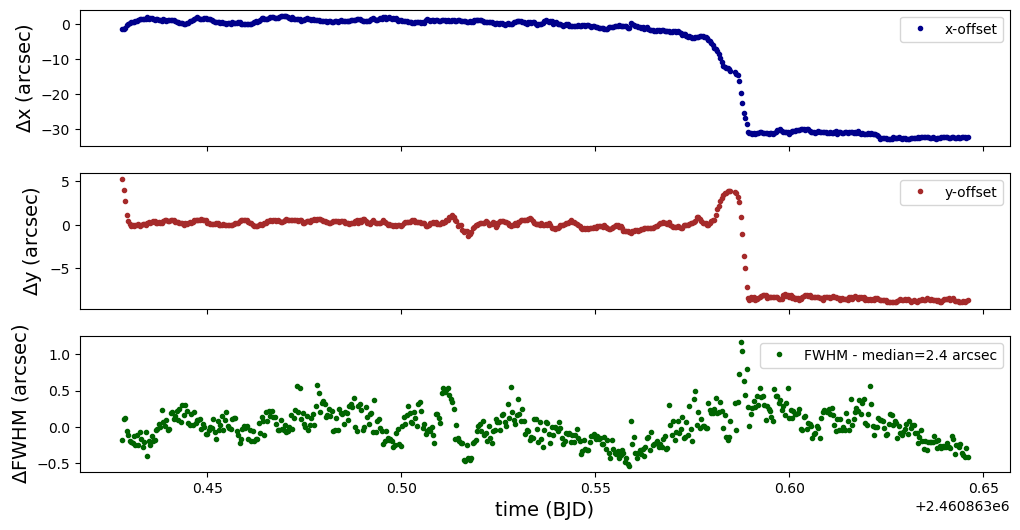

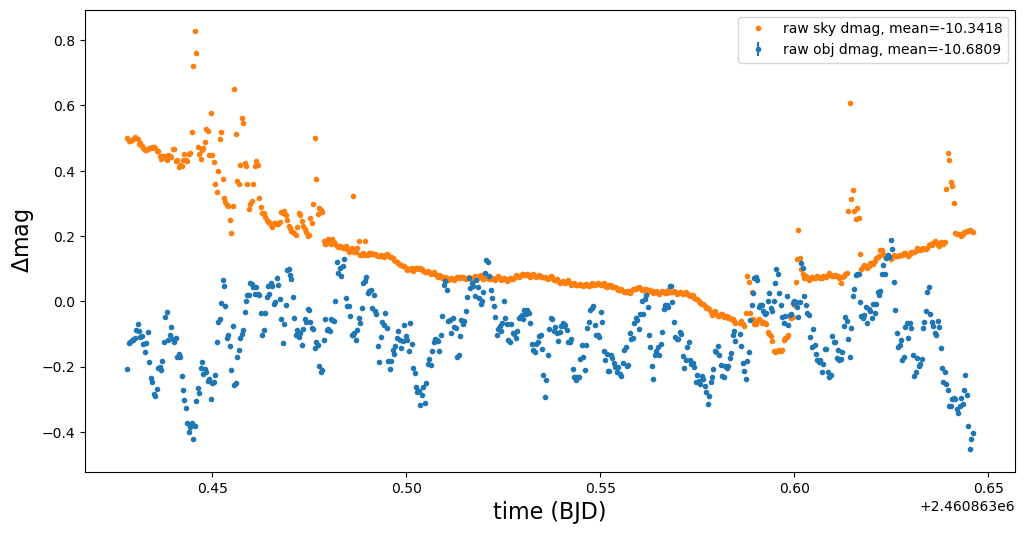

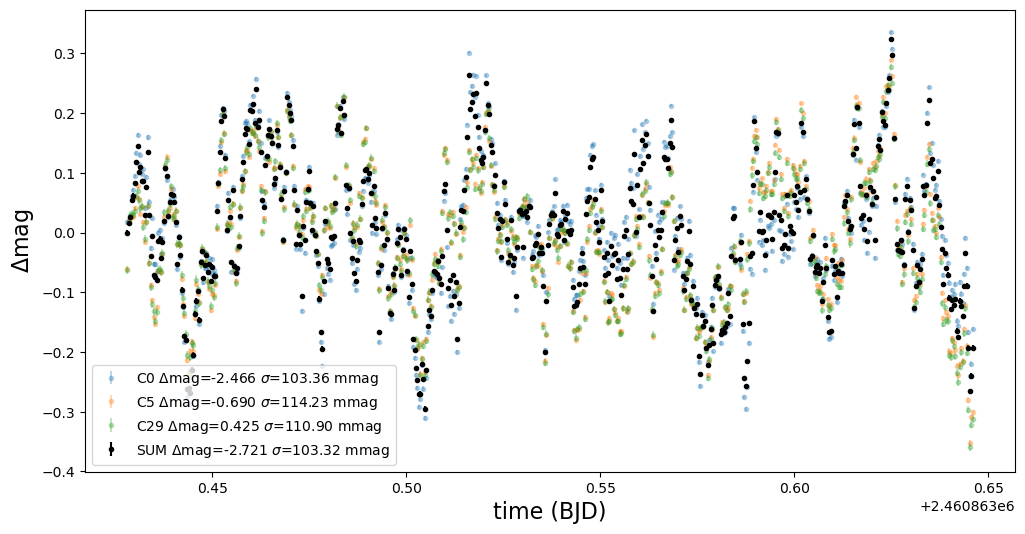

       TIME                x         ...        diffmagsum      
------------------ ----------------- ... -----------------------
2460863.4280860405 355.0329090916567 ... -4.4365467203988374e-05
 2460863.428463259 354.7829090916567 ...    0.016250741566382843
2460863.4288404076 355.7829090916567 ...    0.026600748913956807
 2460863.429217742 358.2829090916567 ...     0.05420284116628693
2460863.4295959896 359.2829090916567 ...     0.06191166179999108
  2460863.42997212 359.7829090916567 ...     0.08311494546000375
2460863.4303491535 360.7829090916567 ...      0.1179259672759212
               ...               ... ...                     ...
2460863.6437372207 261.5329090916567 ...    -0.09003577253473871
 2460863.644115781 262.0329090916567 ...    -0.03434677821401522
 2460863.644492651 262.2829090916567 ...    -0.08886871784637762
 2460863.644872137 263.0329090916567 ...     -0.1929441454460985
2460863.6452485095 262.5329090916567 ...    -0.26544672339653985
2460863.6456255186 262.03

In [8]:
catalog = 'CATALOG_PHOT_AP010'
target=18
comps=[0,5,29]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [9]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs2/20250706_s4c2_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    3483   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU   4690   261R x 2339C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

Below we print one of the catalog extensions

In [10]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

Then we can print all column names to check the data available in each catalog

In [11]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0573', 'EFE0573', 'FO0574', 'EFO0574', 'FE0574', 'EFE0574', 'FO0575',
       'EFO0575', 'FE0575', 'EFE0575'],
      dtype='object', length=2339)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-03 12:09:44,967 astropop - INFO - Normalization disabled.  [__init__]


2025-11-03 12:09:44,967 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-03 12:09:44,993 root - INFO - Source index: i=18   [pipeline_lib]


2025-11-03 12:09:44,993 | INFO | Source index: i=18 


2025-11-03 12:09:44,994 root - INFO - Source RA=258.15169971781893 Dec=-24.245720885314018 mag=-17.6291+-0.0002  [pipeline_lib]


...

2025-11-03 12:09:45,102 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 12:09:45,330 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 12:09:45,330 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-03 12:09:45,335 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-03 12:09:45,335 | INFO | Substituting symbol \perp from STIXGeneral


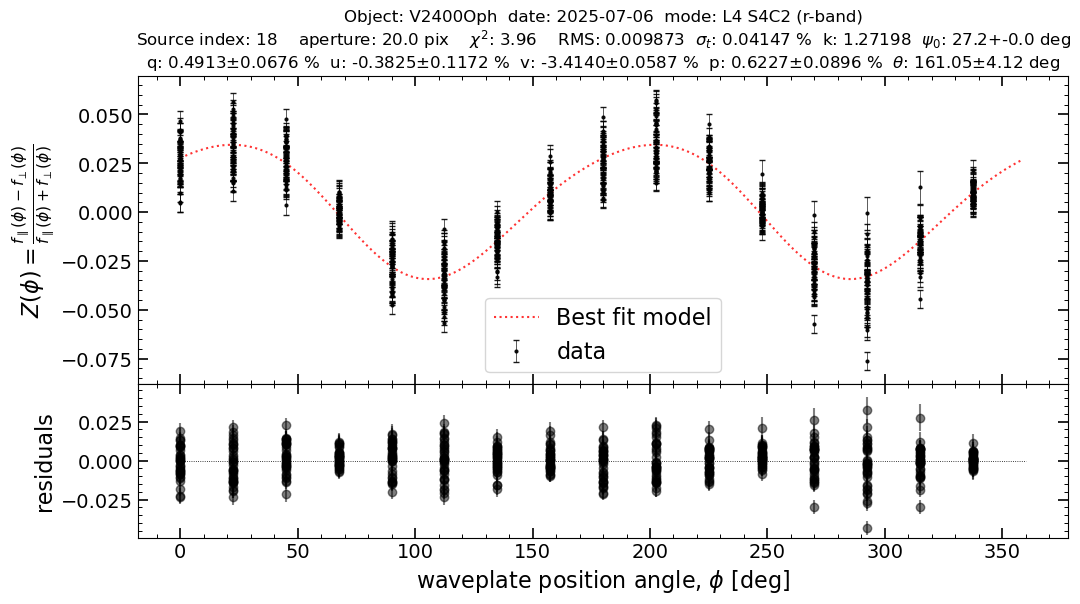

In [12]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [13]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250706/sparc4acs2/20250706_s4c2_Gain2_1.0_Conventional_2_V2400Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 18
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 6
APERTURE_RADIUS : 20.0
NEXPS : 576
MAG : -17.6291+-0.0002
RA : 258.15169971781893
DEC : -24.245720885314018
FWHM : 4.9825004633397505
X1 : 345.4063657489899
Y1 : 445.8240042556237
X2 : 364.65945243432344
Y2 : 409.15004184817656
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5 135.  157.5
 180.  202.5 225.  247.5 270.  292.5 315.  337.5   0.   22.5  45.   67.5
  90.  112.5 135.  157.5 180.  202.5 225.  247.5 270.  292.5 315.  337.5
   0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5 135.  157.5
 180.  202.5 225.  247.5 270.  292.5 315.  337.5   0.   22.5  45.   67.5
  90.  112.5 135.  157.5 1

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [14]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 0.62+-0.09 %  Angle of polarization: 161+-4 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [15]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [16]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

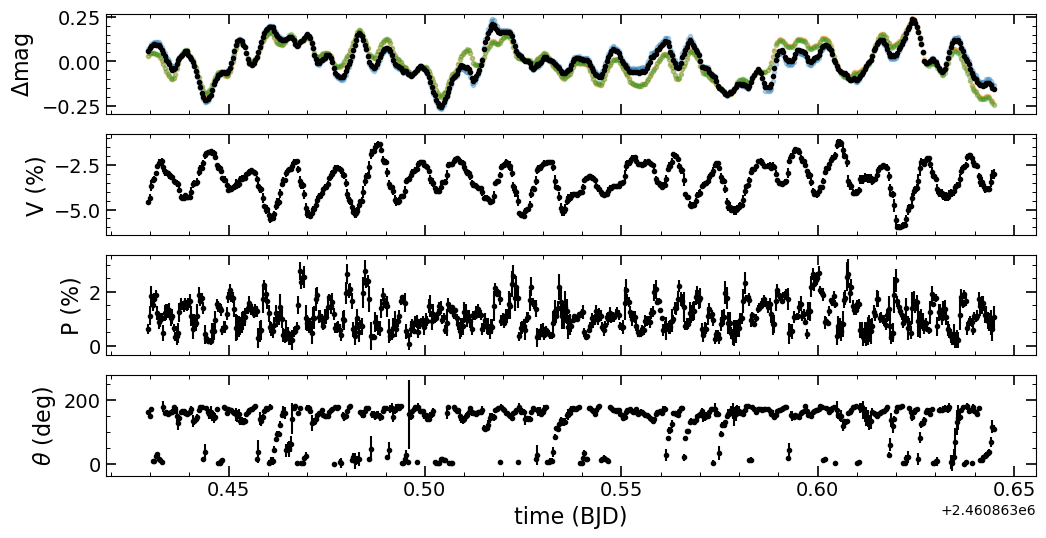

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0683805739506802,0.0012549653943726934,0.02898612285039981,0.0014388945142192577,0.030774120527608417,0.0023115366615387386,2460863.429579881,345.4063657489899,445.8240042556237,364.65945243432344,409.15004184817656,4.721471712041801,-12.918711308114375,0.001236009472794378,-15.57613829510785,0.002098904250138303,0.05960849001654012,0.006141724407074594,0.0019002534051383072,160.28988285939425,8.848858038037902
0.0801523181773085,0.0012397198909046715,0.0432389109817688,0.0014253881952610312,0.04492333786604519,0.0023022661894818866,2460863.4299577186,345.1563657489899,442.0740042556237,364.40945243432344,405.40004184817656,4.736001223520285,-12.932807337765803,0.001220597647129856,-15.577932638682721,0.0020974962869547147,0.07191017609309647,0.011230578346346833,0.003446923065953703,148.67255124444267,8.777998482895889
0.09458768383080418,0.0012370292595984588,0.04467270921252009,0.0014225664276420582,0.04743773055127498,0.0022997256241989402,2460863.430335058,346.1563657489899,438.0740042556237,365.40945243432344,401.40004184817656,4.672389101819627,-12.935352003736362,0.0012175928199134683,-15.568798616630117,0.0020964440730531567,0.0835888641162601,0.01833760587856885,0.0039191356088406635,171.67445776695808,6.112427061366791
0.10370308991694444,0.0012343108268234014,0.04703929906235338,0.001419673217233144,0.049223953130663745,0.0022972622798371352,2460863.4307128494,348.6563657489899,433.5740042556237,367.90945243432344,396.90004184817656,4.6367873099273735,-12.937744006017795,0.0012146830870627243,-15.563581955869916,0.0020952432406086885,0.09119752715789353,0.015046110801461152,0.0021565375411087863,9.630819602216322,4.099197094156833
0.10948371324150585,0.001233217486012161,0.04575872613445853,0.0014182111528674838,0.046538922130896054,0.0022932388543829346,2460863.4310906054,349.6563657489899,431.3240042556237,368.90945243432344,394.65004184817656,4.586640975008944,-12.936330938325263,0.001213424981868516,-15.558019057639154,0.002091385216861686,0.09534735769612368,0.017180398863811307,0.00247566315895406,9.64094384848012,4.121206201750483
0.10581768386097679,0.0012345764907414074,0.04065671467498433,0.00141852001763279,0.04171539385531631,0.0022885752072161316,2460863.4314672104,350.1563657489899,430.3240042556237,369.40945243432344,393.65004184817656,4.586640975008944,-12.932138699075196,0.0012148146546706732,-15.557792786027116,0.0020848574760382967,0.09138139005809442,0.018715053975131547,0.001960579270516692,22.49880541015584,2.9961210483969904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-0.11315851810969058,0.0013339388799829296,-0.202570171474715,0.0014722265721608739,-0.2083869710556705,0.0021571280930408024,2460863.642590524,252.4063657489899,404.8240042556237,271.65945243432344,368.15004184817656,4.419545329522962,-12.729819701028358,0.0013173048700264797,-15.58024540502181,0.001842327132543533,-0.13339022698343683,0.011447779742327857,0.003019184753723854,24.48231259197803,7.542832400699527
-0.10107567254661376,0.0013196372315407167,-0.19448597598574047,0.0014581084079158333,-0.20007925657589887,0.0021422109505967943,2460863.6429682975,252.4063657489899,404.3240042556237,271.65945243432344,367.65004184817656,4.419545329522962,-12.73905095395686,0.0013028068982579805,-15.578279040765901,0.0018343044639629418,-0.12219260979902558,0.011804935197389007,0.0029008210482815784,27.9096567270116,7.027864244371528


In [17]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)